### Pandas(Python Data Analysis Library)

* Pandas는 파이썬에서 사용하는 데이터분석 라이브러리로 `행과 열로 이루어진 데이터 객체를 조작`한다.
* 보다 안전적이고 빠르게 `대용량의 데이터를 처리`하는데 매우 유용한 도구이다.
* pandas 기본적으로 정의되어 있는 자료구조 `1차원 Series와 2차원 배열인 DataFrame`을 사용한다.
* pandas의 자료구조들은 빅데이터분석에 있어 높은 수준의 성능을 보여준다.

#### 참고 site

* pandas문서 : http://pandas.pydata.org/pandas-docs/stable/index.html
* 자료구조 : http://pandas.pydata.org/pandas-docs/stable/dsintro.html

### Padas cheet Sheet

<img src = './images/23.데이터분석_pandas_01_cheat_sheet-1.png'>
<img src = './images/23.데이터분석_pandas_01_cheat_sheet-2.png'>

In [1]:
%matplotlib inline
# 이는 IPython 에서 제공하는 Rich output 에 대한 표현 방식인데요,
# 도표와 같은 그림, 소리, 애니메이션 과 같은 결과물들을 Rich output 이라 합니다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
print(pd.__version__)

pd.show_versions()  # full package version

1.4.4


C:\Users\woori\anaconda3\lib\site-packages\_distutils_hack\__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")



INSTALLED VERSIONS
------------------
commit           : ca60aab7340d9989d9428e11a51467658190bb6b
python           : 3.9.13.final.0
python-bits      : 64
OS               : Windows
OS-release       : 10
Version          : 10.0.19044
machine          : AMD64
processor        : Intel64 Family 6 Model 58 Stepping 9, GenuineIntel
byteorder        : little
LC_ALL           : None
LANG             : None
LOCALE           : Korean_Korea.949

pandas           : 1.4.4
numpy            : 1.21.5
pytz             : 2022.1
dateutil         : 2.8.2
setuptools       : 63.4.1
pip              : 22.2.2
Cython           : 0.29.32
pytest           : 7.1.2
hypothesis       : None
sphinx           : 5.0.2
blosc            : None
feather          : None
xlsxwriter       : 3.0.3
lxml.etree       : 4.9.1
html5lib         : None
pymysql          : None
psycopg2         : None
jinja2           : 2.11.3
IPython          : 7.31.1
pandas_datareader: None
bs4              : 4.11.1
bottleneck       : 1.3.5
brotli  

#### pandas 자료 구조

<img src = './images/23.데이터분석_pandas_02_자료구조.png'>

#### 1. Series

* `인덱스와 값을 가진 1차원 배열`이다
* 만드는 방법은 `값의 list를 전달해서 생성`한다
* 인덱스는 `자동으로 정의되는 정수인덱스를 사용`한다
* 단, 인덱스를 정의하지 않으면 `0부터 순차적으로 부여`된다.

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
5    NaN
6    6.0
7    7.0
8    8.0
dtype: float64


<AxesSubplot:>

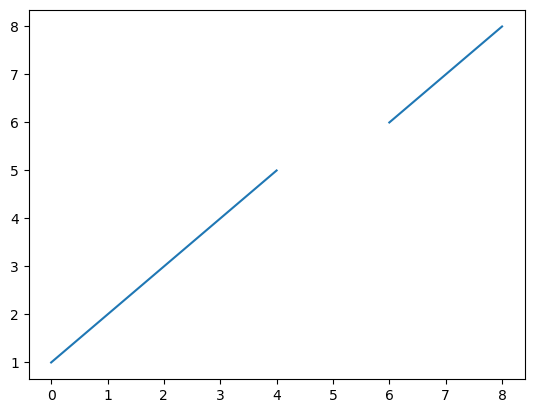

In [5]:
# 1. Series 데이터 생성(1) - 기본

ser1 = pd.Series([1,2,3,4,5,np.nan,6,7,8])
print(ser1)
ser1.plot()

In [7]:
ser2 = pd.Series([1,2,3,4,5,np.nan,6,7,8,print])
print(ser2)
# ser2.plot : print()함수는 자료로서는 에러는 아니지만
# 수치데이터가 아니기 때문에 시각화시에은 에러가 발생!

0                            1
1                            2
2                            3
3                            4
4                            5
5                          NaN
6                            6
7                            7
8                            8
9    <built-in function print>
dtype: object


In [10]:
# 2. Series데이터 생성(2) - 인덱스 정의
# 1) 기본인덱스(숫자)

ser3 = pd.Series([3,6,9,12], index=None)
print(ser3)
print(ser3[1])
print(ser3[3])

0     3
1     6
2     9
3    12
dtype: int64
6
12


In [13]:
# 2) 문자인덱스

ser4 = pd.Series([3,6,9,12], index=['A','B','C','D'])
print(ser4)
print(ser4['B'], ser4['D'])
print(ser4[1], ser4[3])

A     3
B     6
C     9
D    12
dtype: int64
6 12
6 12


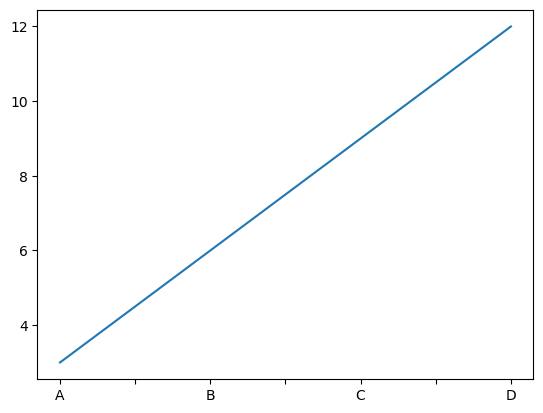

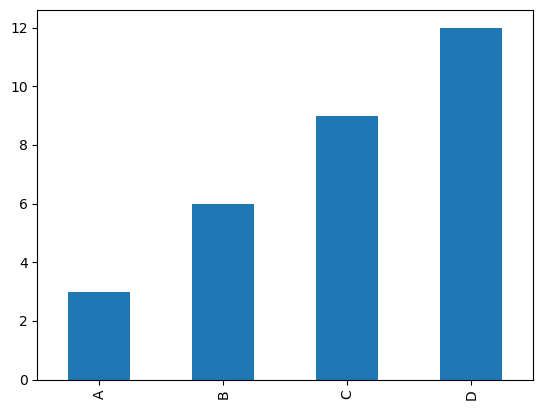

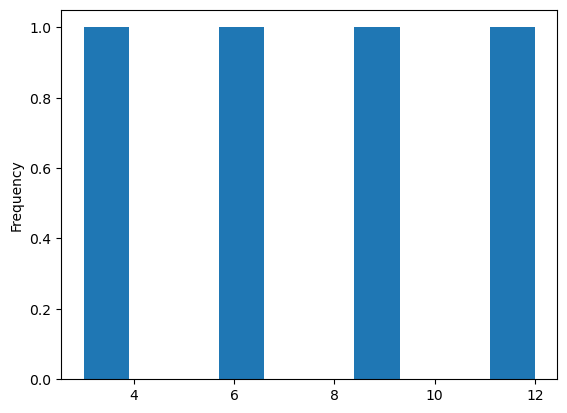

In [18]:
# 시각화

ser4.plot()
plt.show()
ser4.plot(kind='bar')
plt.show()
ser4.plot(kind='hist')
plt.show()

In [21]:
# 3. Series데이터 생성(3) : 인덱스(키)와 값으로 정의

employee = {'손흥민':9000, '홍길동':5000, '홍길순':8500, '홍미녀':7500}
print(type(employee))

ser = pd.Series(employee)
print(ser, type(ser))
print(ser['홍길동'],'=',ser[1])

<class 'dict'>
손흥민    9000
홍길동    5000
홍길순    8500
홍미녀    7500
dtype: int64 <class 'pandas.core.series.Series'>
5000 = 5000


In [26]:
# 한글처리
from matplotlib import rc, font_manager

font_name = font_manager.FontProperties(fname='./data/D2Coding.ttc').get_name()
rc('font', family=font_name)
rc('axes', unicode_minus=False)

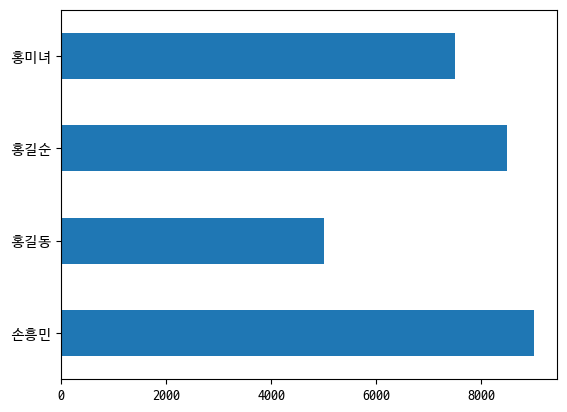

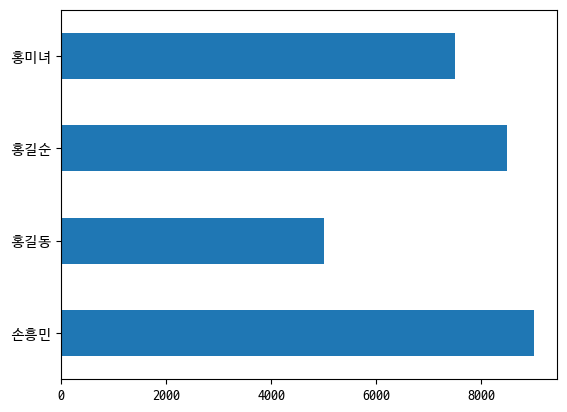

In [28]:
ser.plot(kind='barh')
plt.show()

ser.plot.barh()
plt.show()

#### DataFrame

* 테이블의 형식의 `2차원배열(정확하게는 행렬, Matrix)`

   0  1  2
0  1  2  3
1  4  5  6
2  7  8  9


,0,1,2
0,1,2,3
1,4,5,6
2,7,8,9


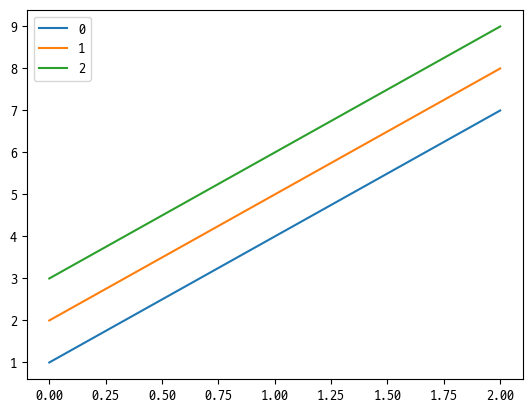

AttributeError: 'list' object has no attribute 'plot'

In [34]:
# 1. DataFrame생성(1) - 2차원 list자료형으로 df을 생성

# pd.DataFrame?

df = pd.DataFrame([[1,2,3],[4,5,6],[7,8,9]])
df
print(df)
display(df)

df.plot()
plt.show()

l = [[1,2,3],[4,5,6],[7,8,9]]
# l.plot() 에러 : list plot속성 없음

In [36]:
# 2. DataFrame 생성(2) - dict자료형으로 df 생성

df = pd.DataFrame({
    '체중' : [80,70,65.5,45.9,70.4],
    '신장' : [168,180,178,160,165],
    '성별' : ['F','M','M','F','F']
})

display(df)

,체중,신장,성별
0,80.0,168,F
1,70.0,180,M
2,65.5,178,M
3,45.9,160,F
4,70.4,165,F


In [37]:
df = pd.DataFrame({
    '체중' : [80,70,65.5,45.9,70.4],
    '신장' : [168,180,178,160,165],
    '성별' : ['F','M','M','F','F']
}, index=['홍길동','손흥민','류현진','홍길순','홍미녀'])

display(df)

,체중,신장,성별
홍길동,80.0,168,F
손흥민,70.0,180,M
류현진,65.5,178,M
홍길순,45.9,160,F
홍미녀,70.4,165,F


In [41]:
# 손흥민의 신장?
# 접근방법 : df['신장'] or df.신장

display(df['신장'])
display(df.신장)
display(df[df.신장==180])

홍길동    168
손흥민    180
류현진    178
홍길순    160
홍미녀    165
Name: 신장, dtype: int64

홍길동    168
손흥민    180
류현진    178
홍길순    160
홍미녀    165
Name: 신장, dtype: int64

,체중,신장,성별
손흥민,70.0,180,M


In [43]:
# 실습
# 1. 성별이 '남자'인 사람만 출력
display(df[df.성별=='M'])

# 2. 신장이 170이상인 사람만 출력
display(df[df.신장>=170])

,체중,신장,성별
손흥민,70.0,180,M
류현진,65.5,178,M


,체중,신장,성별
손흥민,70.0,180,M
류현진,65.5,178,M


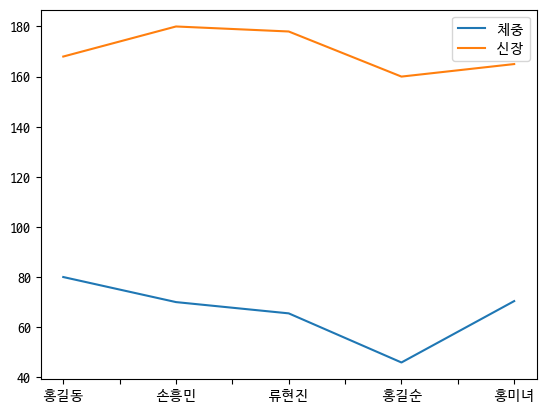

<AxesSubplot:>

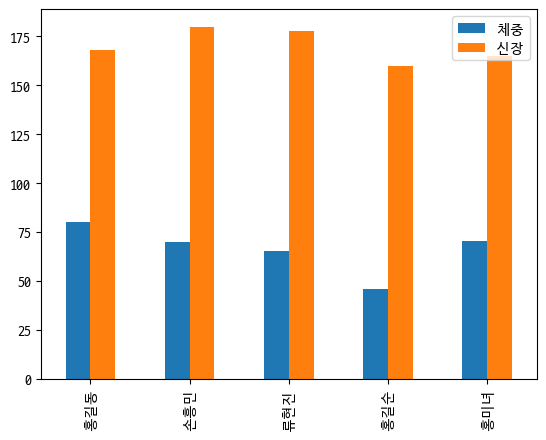

In [45]:
# 3. 시각화
df.plot()
plt.show()

df.plot.bar()
plt.show()

In [51]:
# 3. DataFrame 생성(3) - numpy배열 or dict자료형으로 df 생성

# pd.date_range?
dates = pd.date_range('20221101', periods=6, freq='M')
print(dates, type(dates))

# 1) numpy 배열

df = pd.DataFrame(np.random.randn(6,4),
                 index = dates,
                 columns=['매출액','매출원가','매출이익','영업이익'])
display(df)

DatetimeIndex(['2022-11-30', '2022-12-31', '2023-01-31', '2023-02-28',
               '2023-03-31', '2023-04-30'],
              dtype='datetime64[ns]', freq='M') <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


,매출액,매출원가,매출이익,영업이익
2022-11-30,0.924360,-1.055046,-0.288217,-0.332397
2022-12-31,0.743400,1.248679,-0.623729,-1.243981
2023-01-31,-0.855221,-1.976325,0.624318,-0.160190
2023-02-28,0.032623,-1.747385,-1.134769,-0.124915
2023-03-31,1.032341,1.369616,-2.581038,-0.105168
2023-04-30,1.148966,-0.518312,-1.098789,1.119629


In [53]:
# 2) dict자료형

data = {
    'names' : ['홍길동','손흥민','이강인','류현진', '홍길순'],
    'year' : [2016,2017,2018,2019,2020],
    'point' : [1.5,1.7,2.6,3.6,2.9]
}

df = pd.DataFrame(data, index=pd.date_range('20221124',periods=5))
display(df)

,names,year,point
2022-11-24,홍길동,2016,1.5
2022-11-25,손흥민,2017,1.7
2022-11-26,이강인,2018,2.6
2022-11-27,류현진,2019,3.6
2022-11-28,홍길순,2020,2.9


In [65]:
# 4. DataFram 생성(4) - 직접 index, column을 정의해서 df 생성
display(data)

df = pd.DataFrame(data, columns=['names','year','point', 'bonus'],
                  index = ['Jan','Feb','Mar','Apr', 'May'] )
display(df)
# dict자료형은 열이름이 key 다르거나 새로 추가 되면 NaN 데이터가 생김

{'names': ['홍길동', '손흥민', '이강인', '류현진', '홍길순'],
 'year': [2016, 2017, 2018, 2019, 2020],
 'point': [1.5, 1.7, 2.6, 3.6, 2.9]}

,names,year,point,bonus
Jan,홍길동,2016,1.5,NaN
Feb,손흥민,2017,1.7,NaN
Mar,이강인,2018,2.6,NaN
Apr,류현진,2019,3.6,NaN
May,홍길순,2020,2.9,NaN


In [67]:
# 5. DataFrame 속성

# 1) describe 속성 vs discribe()함수

display(df.describe)  # 속성

display(df.describe()) # 메서드 : df의 기초통계량 정보를 제공

<bound method NDFrame.describe of     names  year  point bonus
Jan   홍길동  2016    1.5   NaN
Feb   손흥민  2017    1.7   NaN
Mar   이강인  2018    2.6   NaN
Apr   류현진  2019    3.6   NaN
May   홍길순  2020    2.9   NaN>

,year,point
count,5.000000,5.000000
mean,2018.000000,2.460000
std,1.581139,0.867756
min,2016.000000,1.500000
25%,2017.000000,1.700000
50%,2018.000000,2.600000
75%,2019.000000,2.900000
max,2020.000000,3.600000


In [71]:
# 2) index, columns, values
display(df.index, type(df.index))
display(df.columns, type(df.columns))
display(df.values)

Index(['Jan', 'Feb', 'Mar', 'Apr', 'May'], dtype='object')

pandas.core.indexes.base.Index

Index(['names', 'year', 'point', 'bonus'], dtype='object')

pandas.core.indexes.base.Index

array([['홍길동', 2016, 1.5, nan],
       ['손흥민', 2017, 1.7, nan],
       ['이강인', 2018, 2.6, nan],
       ['류현진', 2019, 3.6, nan],
       ['홍길순', 2020, 2.9, nan]], dtype=object)

In [75]:
# 3) 특정 컬럼(열)만 출력하기

display(df['names'], df['point'], df.names)

display(df[['names','point']]) # 2개이상 열을 표현할 때

Jan    홍길동
Feb    손흥민
Mar    이강인
Apr    류현진
May    홍길순
Name: names, dtype: object

Jan    1.5
Feb    1.7
Mar    2.6
Apr    3.6
May    2.9
Name: point, dtype: float64

Jan    홍길동
Feb    손흥민
Mar    이강인
Apr    류현진
May    홍길순
Name: names, dtype: object

,names,point
Jan,홍길동,1.5
Feb,손흥민,1.7
Mar,이강인,2.6
Apr,류현진,3.6
May,홍길순,2.9


In [78]:
# 6. DataFrame 조작하기
# 1) 특정열의 값을 일괄로 변경하기
# NaN(결측치)인 값을 특정값으로 변경
# df.컬럼명 = 값 or df['컬럼명'] = 값

df.bonus = 0.5
df
df['bonus'] = 0.7
df

,names,year,point,bonus
Jan,홍길동,2016,1.5,0.7
Feb,손흥민,2017,1.7,0.7
Mar,이강인,2018,2.6,0.7
Apr,류현진,2019,3.6,0.7
May,홍길순,2020,2.9,0.7


In [81]:
# 2) 컬럼추가하기(1) - 컬럼명이 없을 경우에는 자동으로 추가하기
# 컬럼을 추가할 경우에는 df['컬럼명']의 형태로 추가해야 한다
# df.컬럼명의 형태로 추가할 경우에는 에러는 발생하지 않지만, 추가x
df['penalty'] = 10
df

df.xxxx = 20  # 에러는 아니지만 추가 불가
df


,names,year,point,bonus,penalty
Jan,홍길동,2016,1.5,0.7,10
Feb,손흥민,2017,1.7,0.7,10
Mar,이강인,2018,2.6,0.7,10
Apr,류현진,2019,3.6,0.7,10
May,홍길순,2020,2.9,0.7,10


In [85]:
# 3) 컬럼추가하기(3) - 개별로 값을 추가

df['age'] = np.arange(21,26)
df

df['yyy'] = [1,2,3,4,5]  # 행의 갯수가 다를 경우에는 에러발생
df

# df['zzz'] = [1,2,3,4,5,6]
# df

,names,year,point,bonus,penalty,age,yyy
Jan,홍길동,2016,1.5,0.7,10,21,1
Feb,손흥민,2017,1.7,0.7,10,22,2
Mar,이강인,2018,2.6,0.7,10,23,3
Apr,류현진,2019,3.6,0.7,10,24,4
May,홍길순,2020,2.9,0.7,10,25,5


In [92]:
# 4) 컬럼 삭제하기(1) - df.drop()

# df.drop?

df.columns

# drop()함수는 실행만 , 결과는 저장하지 않는다
# 결과를 저장하려면 inplace = True 설정
# 지정 컬럼이 없을 경우에는 에러가 발생한다.
df = df.drop(['yyy'], axis =1)  # 1 = 열을 의미


In [96]:
df.drop(['age'],axis=1, inplace=True)

In [97]:
df

,names,year,point,bonus,penalty
Jan,홍길동,2016,1.5,0.7,10
Feb,손흥민,2017,1.7,0.7,10
Mar,이강인,2018,2.6,0.7,10
Apr,류현진,2019,3.6,0.7,10
May,홍길순,2020,2.9,0.7,10


In [100]:
df.drop(['bonus'], axis=1, inplace=True)

In [101]:
df

,names,year,point,penalty
Jan,홍길동,2016,1.5,10
Feb,손흥민,2017,1.7,10
Mar,이강인,2018,2.6,10
Apr,류현진,2019,3.6,10
May,홍길순,2020,2.9,10


In [102]:
# 5) 컬럼삭제하기(2) - del명령
# del df.xxxx 에어
# del df['xxx'] 
del df['penalty']  # 결과가 저장, 컬럼이 없으면 에러 발생
df

,names,year,point
Jan,홍길동,2016,1.5
Feb,손흥민,2017,1.7
Mar,이강인,2018,2.6
Apr,류현진,2019,3.6
May,홍길순,2020,2.9


In [106]:
# 6) 인덱스 변경하기

df.index
df = pd.DataFrame(data, index=['Mon','Thu','Wed','Thr','Fri'])
df

#### 3. pandas 기본함수

##### 1) csv파일 -  load / save
* df = `pd.read_csv(파일이름)`
* df.`to_csv(파일이름)`

##### 2) DataFrame확인
* df.shape : 모양
* df.info()
* df.columns
* df.dtypes
* df.head(n) : 맨 처음부터 n개의 자료만 조회, n은 생략가능 = 기본값 5
* df.tail(n) : 맨 뒤에서부터 n개의 자료만 조회, n은 생략가능 = 기본값 5

##### 3) null or NaN갯수 확인
* `df.isnull().sum()`
* `df.isna().sum()`

##### 4) 특정 컬럼/행 삭제
* df.`drop([col1, col1...... col n], axis = 1)`
* df.`drop(['row'])`

##### 5) 특정 컬럼명 변경
* df = df.`rename(colulmn={'A':'B'})`

##### 6) 특정 컬럼의 값을 새로운 컬럼으로 만들기
* df['A'] = df['B'].str[:5]
* df['A'] = df['B'].str[:-5]

##### 7) 컬럼순서 변경
* df = pd.DataFrame(df, columns = ['C','B','A'])

##### 8) DataFrame 합치기
* df_result = pd.`concat([df1, df2], ingnore_index=True)`
* df_result = pd.`merge([df1, df2])`

##### 9)  DataFrame 중복확인 및 제거
* df.`duplicated()` : 중복확인
* df.`drop_duplicated()` : 중복제거

##### 10) DataFrame 행/열의 위치 확인
* df.`loc()` : 이름위치 확인
* df.`iloc()` : 인덱스로 위치 확인

In [109]:
df = pd.read_csv('./data/movie/user_rating_mean.csv')

In [120]:
df.isnull().sum()

user_id    0
rating     0
dtype: int64

In [121]:
df.isna().sum()

user_id    0
rating     0
dtype: int64

In [126]:
df = pd.DataFrame(data, columns=['names','year','point', 'bonus'],
                  index = ['Jan','Feb','Mar','Apr', 'May'] )


,names,year,point,bonus
Jan,홍길동,2016,1.5,NaN
Feb,손흥민,2017,1.7,NaN
Mar,이강인,2018,2.6,NaN
Apr,류현진,2019,3.6,NaN
May,홍길순,2020,2.9,NaN


In [128]:
# 1. head / tail

display(df.head(3))
display(df.tail(3))

,names,year,point,bonus
Jan,홍길동,2016,1.5,NaN
Feb,손흥민,2017,1.7,NaN
Mar,이강인,2018,2.6,NaN


,names,year,point,bonus
Mar,이강인,2018,2.6,NaN
Apr,류현진,2019,3.6,NaN
May,홍길순,2020,2.9,NaN


In [134]:
# 2. loc : df에서 열이나 행을 선택하는 함수
# 숫자인덱스 사용을 불가능, 이름으로 행 / 열 접근

df.loc['Mar']
df.loc['Mar':'May']

# df.loc[3:5] 숫자인덱스 사용불가

,names,year,point,bonus
Mar,이강인,2018,2.6,NaN
Apr,류현진,2019,3.6,NaN
May,홍길순,2020,2.9,NaN


In [138]:
display(df[['year','names']])
display(df.loc['Mar':'May',['year','names']])
display(df.loc['Mar':'May','names':'year'])

,year,names
Jan,2016,홍길동
Feb,2017,손흥민
Mar,2018,이강인
Apr,2019,류현진
May,2020,홍길순


,year,names
Mar,2018,이강인
Apr,2019,류현진
May,2020,홍길순


,names,year
Mar,이강인,2018
Apr,류현진,2019
May,홍길순,2020


In [144]:
# 3. iloc() : 숫자인덱스로만 사용

display(df.iloc[3])
display(df.iloc[1:3])

# 행과 열의 범위 지정
display(df.iloc[1:3,0:2])

# 직접 위치를 지정
display(df.iloc[1,0], df.iloc[1,1], df.iloc[1,2])

# df.iloc?

names     류현진
year     2019
point     3.6
bonus     NaN
Name: Apr, dtype: object

,names,year,point,bonus
Feb,손흥민,2017,1.7,NaN
Mar,이강인,2018,2.6,NaN


,names,year
Feb,손흥민,2017
Mar,이강인,2018


'손흥민'

2017

1.7

In [149]:
# 4. 블리언인덱싱

display(df[df.year>2017])
display(df.loc[df.year>2017])

,names,year,point,bonus
Mar,이강인,2018,2.6,NaN
Apr,류현진,2019,3.6,NaN
May,홍길순,2020,2.9,NaN


,names,year,point,bonus
Mar,이강인,2018,2.6,NaN
Apr,류현진,2019,3.6,NaN
May,홍길순,2020,2.9,NaN


In [161]:
# 5. 행삭제

df = pd.DataFrame(np.random.rand(6,4))
df.columns = ['A', 'B', 'C', 'D']
df.index = pd.date_range('20221124',periods=6)
display(df)

display(type(df.index))

df = df.drop(['2022-11-24','2022-11-25'])


,A,B,C,D
2022-11-24,0.932934,0.006879,0.465079,0.381029
2022-11-25,0.414404,0.316347,0.328281,0.545418
2022-11-26,0.560850,0.570377,0.182881,0.032570
2022-11-27,0.993160,0.422815,0.734997,0.574660
2022-11-28,0.131804,0.615894,0.962416,0.342761
2022-11-29,0.178067,0.376623,0.044004,0.055440


pandas.core.indexes.datetimes.DatetimeIndex

In [162]:
df

,A,B,C,D
2022-11-26,0.560850,0.570377,0.182881,0.032570
2022-11-27,0.993160,0.422815,0.734997,0.574660
2022-11-28,0.131804,0.615894,0.962416,0.342761
2022-11-29,0.178067,0.376623,0.044004,0.055440


In [167]:
# 6 열삭제
# 1개의 열 삭제

df = df.drop(['A'], axis = 1)
df


KeyError: "['A'] not found in axis"

In [168]:
df = df.drop(['B','D'], axis = 1)
df

,C
2022-11-26,0.182881
2022-11-27,0.734997
2022-11-28,0.962416
2022-11-29,0.044004


In [170]:
# 7. 열이름 변경

df = df.rename(columns={'C':'CC'})
df

,CC
2022-11-26,0.182881
2022-11-27,0.734997
2022-11-28,0.962416
2022-11-29,0.044004


#### 4. pandas의 데이터 분석용 함수
* sum()
* mean()
* var()
* T : pivot()함수
* groupby()
* agg()

In [171]:
df = pd.DataFrame({
    'weight' : [80.0,70.4,65.5,45.9,51.5],
    'height' : [170,180,155,150,160]
})
df

,weight,height
0,80.0,170
1,70.4,180
2,65.5,155
3,45.9,150
4,51.5,160


In [175]:
# 1. sum
# axis = 0(행이 추가 = 열의 합계가 생김)
# axis = 1(열이 추가 =  행의 합계 생김)

# df.sum?
display(df.sum())
display(df.sum(axis=0))
display(df.sum(axis=1))

weight    313.3
height    815.0
dtype: float64

weight    313.3
height    815.0
dtype: float64

0    250.0
1    250.4
2    220.5
3    195.9
4    211.5
dtype: float64

In [181]:
# 2. mean()
display(df.mean())
display(df.mean(axis=0))
display(df.mean(axis=1))

print(f'신장의평균 = {df.height.mean()}')
print(f'체중의평균 = {df.weight.mean()}')

weight     62.66
height    163.00
dtype: float64

weight     62.66
height    163.00
dtype: float64

0    125.00
1    125.20
2    110.25
3     97.95
4    105.75
dtype: float64

신장의평균 = 163.0
체중의평균 = 62.660000000000004


In [184]:
# 3. var() : 분산
a = [10,20,30,40,50]
b = [10,30,30,30,50]

df_a = pd.DataFrame(a)
df_b = pd.DataFrame(b)

# 두 집단의 평균 비교
print(f'a 집단의 평균 = {df_a.mean()}')
print(f'b 집단의 평균 = {df_b.mean()}')

# 두 집단의 분산 비교
print(f'a 집단의 평균 = {df_a.var()}')
print(f'b 집단의 평균 = {df_b.var()}')

# 분산값이 a(250)>b(200)의 의미는 a가 b보다 자료가 넓게 분포되어 있다.

a 집단의 평균 = 0    30.0
dtype: float64
b 집단의 평균 = 0    30.0
dtype: float64
a 집단의 평균 = 0    250.0
dtype: float64
b 집단의 평균 = 0    200.0
dtype: float64


In [189]:
# 4. pivot vs melt
# pivot(T)는 세로를 가로로, melt는 가로를 세로로

display(df_a)
display(df_a.T)
display(df_a.T.melt())

,0
0,10
1,20
2,30
3,40
4,50


,0,1,2,3,4
0,10,20,30,40,50


,variable,value
0,0,10
1,1,20
2,2,30
3,3,40
4,4,50


In [190]:
df2 = pd.DataFrame({
    'A':range(1,5),
    'B':pd.date_range('20221124', periods=4),
    'C':pd.Series(1, index=list(range(4)),dtype='float32'),
    'D':np.array([3]*4, dtype='int32'),
    'E':pd.Categorical(['test','train','test','train']),
    'F':'foo',
})
df2

,A,B,C,D,E,F
0,1,2022-11-24,1.0,3,test,foo
1,2,2022-11-25,1.0,3,train,foo
2,3,2022-11-26,1.0,3,test,foo
3,4,2022-11-27,1.0,3,train,foo


In [197]:
# 5. sort_index(axis, ascending)
# df.sort_index?

display(df2.sort_index(axis=0, ascending=False))
display(df2.sort_index(axis=1, ascending=False))

,A,B,C,D,E,F
3,4,2022-11-27,1.0,3,train,foo
2,3,2022-11-26,1.0,3,test,foo
1,2,2022-11-25,1.0,3,train,foo
0,1,2022-11-24,1.0,3,test,foo


,F,E,D,C,B,A
0,foo,test,3,1.0,2022-11-24,1
1,foo,train,3,1.0,2022-11-25,2
2,foo,test,3,1.0,2022-11-26,3
3,foo,train,3,1.0,2022-11-27,4


In [202]:
# 6. sort_values(by)
# df2.sort_values?

display(df2.sort_values(by='E'))
display(df2.sort_values(by=['E','A']))

,A,B,C,D,E,F
0,1,2022-11-24,1.0,3,test,foo
2,3,2022-11-26,1.0,3,test,foo
1,2,2022-11-25,1.0,3,train,foo
3,4,2022-11-27,1.0,3,train,foo


,A,B,C,D,E,F
0,1,2022-11-24,1.0,3,test,foo
2,3,2022-11-26,1.0,3,test,foo
1,2,2022-11-25,1.0,3,train,foo
3,4,2022-11-27,1.0,3,train,foo


In [203]:
df3 = pd.DataFrame(np.random.rand(4,3),
                  columns=['b', 'd', 'e'],
                  index=['서울','부산','대구','인천'])
df3

,b,d,e
서울,0.071694,0.950586,0.057745
부산,0.867600,0.709293,0.414800
대구,0.363214,0.780869,0.369586
인천,0.490811,0.104121,0.143290


In [212]:
# 7. apply() : 특정함수를 적용

# df2.apply?

# 1) 일반함수

def f(x,y): return x+y
print('func=', f(1,1))

# 2) lambda함수
l = lambda x,y:x+y
print('lambda = ', l(1,1))

# 3) apply()함수
func = lambda x:x.max()-x.min()

print(df3.apply(func, axis=0))
print()
print(df3.apply(func, axis=1))
print()
print(df3.apply(lambda x:x.max()-x.min(),axis=1))

func= 2
lambda =  2
b    0.795906
d    0.846465
e    0.357055
dtype: float64

서울    0.892842
부산    0.452800
대구    0.417655
인천    0.386690
dtype: float64

서울    0.892842
부산    0.452800
대구    0.417655
인천    0.386690
dtype: float64


In [209]:
df3


,b,d,e
서울,0.071694,0.950586,0.057745
부산,0.867600,0.709293,0.414800
대구,0.363214,0.780869,0.369586
인천,0.490811,0.104121,0.143290


### 연습문제
#### 1. 시리즈 만들기


In [6]:
# 1. 시리즈 만들기
# 인덱스 점수
# 철수   100
# 영희   200
# 아름   300
dict_data = {'철수':100,'영희':200,'아름':300}
s_data = pd.Series(dict_data)
print(s_data)

철수    100
영희    200
아름    300
dtype: int64


In [9]:
# 2. 순이 인덱스에 400 추가하고, 철수를 삭제 하시오
s_data.loc['순이'] = 400
print(s_data)
s_data.drop('철수')

철수    100
영희    200
아름    300
순이    400
dtype: int64


영희    200
아름    300
순이    400
dtype: int64

In [ ]:
# 3. 인덱스를 기준으로 오름 차순 정렬하라.
# s = Series(np.random.raniint(10,size=4), ['b','c', 'a', 'd'])

In [ ]:
# 4. 데이터프레임에서 현재가 컬러만 출력해 보세요
data = [
    ["037730", '3R', 1510,7.36],
    ['033630', '3SOFT', 1700,1.65],
    ['005760', 'ACTS', 1185, 1.28]
]
columns = ['종목코드', '종목명', '현재가', '등락율']
df = pd.DataFrame(data=data , columns=columns)
df
df.set_index('종목코드', inplace=True)
df

In [ ]:
# 4-1) 첫번째와 세번째 행을 동시에 인덱싱하세요

In [23]:
# 4-2) 현재가가 1500 이상인 값만 가져와 보세요
df[df['현재가' >= 1500]]

TypeError: '>=' not supported between instances of 'str' and 'int'

In [29]:
# 4-3) 목표가 컬럼을 추가하세요. 목표가는 현재가에서 10% 상승한 가격 입니다
df
df['목표가'] = df['현재가'] * 1.1
df

,종목명,현재가,등락율,목표가
종목코드,,,,
037730,3R,1510,7.36,1661.0
033630,3SOFT,1700,1.65,1870.0
005760,ACTS,1185,1.28,1303.5


In [40]:
# 5. 컬럼 이름 변경

df = pd.DataFrame(data= [[1,2,3],[4,5,6]], columns= ['A','B','C'])

df.columns = ['a','b','c']

df.rename(columns = {'a','b','c'},{'A', 'B','C'}, inplace = True)

SyntaxError: positional argument follows keyword argument (2080627855.py, line 7)

#### 5. pandas를 이용한 데이터분석   (data 폴더에 pandas 폴더 붙혀넣기)

In [53]:
df = pd.read_csv('./data/pandas/input.csv')
result = df.loc[df['Cost']>600]
result.to_csv('./data/pandas/cost_result.csv')
df

,Supplier Name,Invoice Number,Part Number,Cost,Purchase Date
0,A,001-1001,2341,500,2014-01-20
1,A,001-1001,2341,500,2014-01-20
2,A,001-1001,2342,750,2014-01-20
3,A,001-1001,2342,750,2014-01-20
4,B,50-9501,7009,250,2018-01-30
5,B,50-9501,7009,250,2018-01-30
6,B,50-9501,6650,125,2018-02-03
7,B,50-9501,6650,12,2018-02-03
8,C,920-4803,3321,615,2017-02-03
9,C,920-4804,3321,615,2017-02-10


In [57]:
# Supplier = 'A'  and cost > 600
df = pd.read_csv('./data/pandas/input.csv')
df
df.loc[df[(['Supplier Name'].str.contains('A'))  & (df['Cost']>600)]]

AttributeError: 'list' object has no attribute 'str'

In [74]:
# 날짜 필터링
df = pd.read_csv('./data/pandas/input.csv')
dates = ['2014-01-20', '2018-02-03']
df
# isin()
# df.isin?
result = df.loc[df['Purchase Date'].isin(dates)]
result.to_csv('./data/pandas/date_result.csv')

#### 6. DataFrame 의 고급 인덱싱

데이터프레임에서 특정한 데이터만 골라내는 것을 인덱싱(indexing)이라고 한다. 앞 절에서는 라벨, 라벨 리스트, 인덱스데이터(정수) 슬라이스의 3가지 인덱싱 값을 사용하여 인덱싱을 하는 방법을 공부하였다. 그런데 Pandas는 numpy행렬과 같이 쉼표를 사용한 (행 인덱스, 열 인덱스) 형식의 2차원 인덱싱을 지원하기 위해 다음과 같은 특별한 인덱서(indexer) 속성도 제공한다.

>* loc : 라벨값 기반의 2차원 인덱싱 
>* iloc : 순서를 나타내는 정수 기반의 2차원 인덱싱

iloc 인덱서¶
iloc 인덱서는 loc 인덱서와 반대로 라벨이 아니라 순서를 나타내는 정수(integer) 인덱스만 받는다. 다른 사항은 loc 인덱서와 같다.

In [100]:
df = pd.DataFrame(np.arange(10, 26).reshape(4, 4),
                  index=["a", "b", "c", "d"],
                  columns=["A", "B", "C", "D"])
df

,A,B,C,D
a,10,11,12,13
b,14,15,16,17
c,18,19,20,21
d,22,23,24,25


In [77]:
df.loc["a"]

A    10
B    11
C    12
D    13
Name: a, dtype: int32

In [78]:
df.loc["b":]

,A,B,C,D
b,14,15,16,17
c,18,19,20,21
d,22,23,24,25


In [79]:
df.loc["b":"c"]

,A,B,C,D
b,14,15,16,17
c,18,19,20,21


In [85]:
df = pd.DataFrame(np.arange(10, 26).reshape(4, 4), columns=["A", "B", "C", "D"])
df

,A,B,C,D
0,10,11,12,13
1,14,15,16,17
2,18,19,20,21
3,22,23,24,25


In [93]:
df.iloc[0,3]

13

In [103]:
df.loc['a','A']
%timeit df.loc['a','A']
%timeit df.at['a','A']


12.4 µs ± 22.5 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)
6.47 µs ± 64.4 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [105]:
df = pd.read_csv('./data/pandas/score.csv')
df

,name,score,iq,academy,game,tv
0,A,90,140,2,1,0
1,B,75,125,1,3,3
2,C,77,120,1,0,4
3,D,83,135,2,3,2
4,E,65,105,0,4,4
5,F,80,123,3,1,1
6,G,83,132,3,4,1
7,H,70,115,1,1,3
8,I,87,128,4,0,0
9,J,79,131,2,2,3


KeyError: False

In [113]:
df = pd.read_csv('./data/pandas/tips.csv')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [116]:
df.head(5)
df.tail(5)

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [131]:
df.describe()  # 요약 통게량

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [130]:
df.smoker.value_counts()  

No     151
Yes     93
Name: smoker, dtype: int64

In [134]:
days = df.day.unique()

i = []
for i in days:
    value = df.loc[df.day==i, 'tip'].mean()
    i.append([i,value])

AttributeError: 'str' object has no attribute 'append'

In [139]:
iris = pd.read_csv('./data/pandas/iris.csv')
iris

col1 = irus['Sepal.Length']
col2 = irus['Sepal.Width']
col3 = irus['Petal.Length']
col4 = irus['Petal.Width']
col5 = irus['Species']

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [141]:
df = pd.read_csv('./data/pandas/wbc_data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,points_worst,symmetry_worst,dimension_worst
0,87139402,B,12.32,12.39,78.85,464.1,0.10280,0.06981,0.03987,0.03700,...,13.50,15.64,86.97,549.1,0.1385,0.1266,0.12420,0.09391,0.2827,0.06771
1,8910251,B,10.60,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.02642,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.19160,0.07926,0.2940,0.07587
2,905520,B,11.04,16.83,70.92,373.2,0.10770,0.07804,0.03046,0.02480,...,12.41,26.44,79.93,471.4,0.1369,0.1482,0.10670,0.07431,0.2998,0.07881
3,868871,B,11.28,13.39,73.00,384.8,0.11640,0.11360,0.04635,0.04796,...,11.92,15.77,76.53,434.0,0.1367,0.1822,0.08669,0.08611,0.2102,0.06784
4,9012568,B,15.19,13.21,97.65,711.8,0.07963,0.06934,0.03393,0.02657,...,16.20,15.73,104.50,819.1,0.1126,0.1737,0.13620,0.08178,0.2487,0.06766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,911320502,B,13.17,18.22,84.28,537.3,0.07466,0.05994,0.04859,0.02870,...,14.90,23.89,95.10,687.6,0.1282,0.1965,0.18760,0.10450,0.2235,0.06925
565,898677,B,10.26,14.71,66.20,321.6,0.09882,0.09159,0.03581,0.02037,...,10.88,19.48,70.89,357.1,0.1360,0.1636,0.07162,0.04074,0.2434,0.08488
566,873885,M,15.28,22.41,98.92,710.6,0.09057,0.10520,0.05375,0.03263,...,17.80,28.03,113.80,973.1,0.1301,0.3299,0.36300,0.12260,0.3175,0.09772
567,911201,B,14.53,13.98,93.86,644.2,0.10990,0.09242,0.06895,0.06495,...,15.80,16.93,103.10,749.9,0.1347,0.1478,0.13730,0.10690,0.2606,0.07810


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 569 non-null    int64  
 1   diagnosis          569 non-null    object 
 2   radius_mean        569 non-null    float64
 3   texture_mean       569 non-null    float64
 4   perimeter_mean     569 non-null    float64
 5   area_mean          569 non-null    float64
 6   smoothness_mean    569 non-null    float64
 7   compactness_mean   569 non-null    float64
 8   concavity_mean     569 non-null    float64
 9   points_mean        569 non-null    float64
 10  symmetry_mean      569 non-null    float64
 11  dimension_mean     569 non-null    float64
 12  radius_se          569 non-null    float64
 13  texture_se         569 non-null    float64
 14  perimeter_se       569 non-null    float64
 15  area_se            569 non-null    float64
 16  smoothness_se      569 non

In [144]:
tips = pd.read_csv('./data/pandas/tips.csv')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
# 1. select
